<a href="https://colab.research.google.com/github/jackyluo-learning/siren-pii-probing/blob/main/Colab_SIREN_Paper_Full_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏛️ SIREN 论文复现 Notebook (Full Paper Reproduction)

按 ACL 2026 论文 **《LLM Safety From Within: Detecting Harmful Content with Internal Representations》**（arXiv:2604.18519）附录 A.1 / Table 6 的方法论组织。所有算法均调用仓库 `siren/` 库。

### 四个模块（已标注每个模块的真实性）：
1. **论文 Figure 7 数值重绘**（模块1）——用论文 Figure 7 数字化得到的 36 个 F1 值重绘曲线。**非本地实测**，仅作参照。
2. **端到端算法验证**（模块2）——在**合成激活**上跑通安全神经元 L1 筛选 → α_l 融合 → MLP 头。用于验证算法接口，**非真实模型表征**。（注：论文的 250× 指**可训练参数量**减少（Fig 5），与此处的神经元稀疏比是两个不同的量。）
3. **流式检测评分演示**（模块3）——在**合成激活**上做前缀均值池化逐 token 打分。论文流式部分**测的是检测延迟、不做拦截**；此处的 early-stop 截断是仓库演示行为，非论文规格。
4. **真实模型层级实测**（模块4）——基座 **Qwen3-4B** + 论文**七个真实安全基准**聚合，mean-pool、C 网格在验证集选、报 Macro-F1，实测跑出 Figure 7 层级曲线，叠加论文 SIREN=0.867/Guard=0.834 参照线。**这是唯一在真实模型 + 真实数据上测量的模块**（gated 数据集需登录，缺失会自动跳过）。

## 步骤 1：克隆 GitHub 仓库与安装依赖

In [1]:
!nvidia-smi
!git clone https://github.com/jackyluo-learning/siren-pii-probing.git
%cd siren-pii-probing
!pip install --quiet torch transformers scikit-learn matplotlib datasets tqdm seaborn

Thu Aug 13 14:28:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 模块 1：论文 Figure 7 数值重绘（参照，非实测）

Successfully saved Figure 7 reproduction to: figure7_reproduction.png


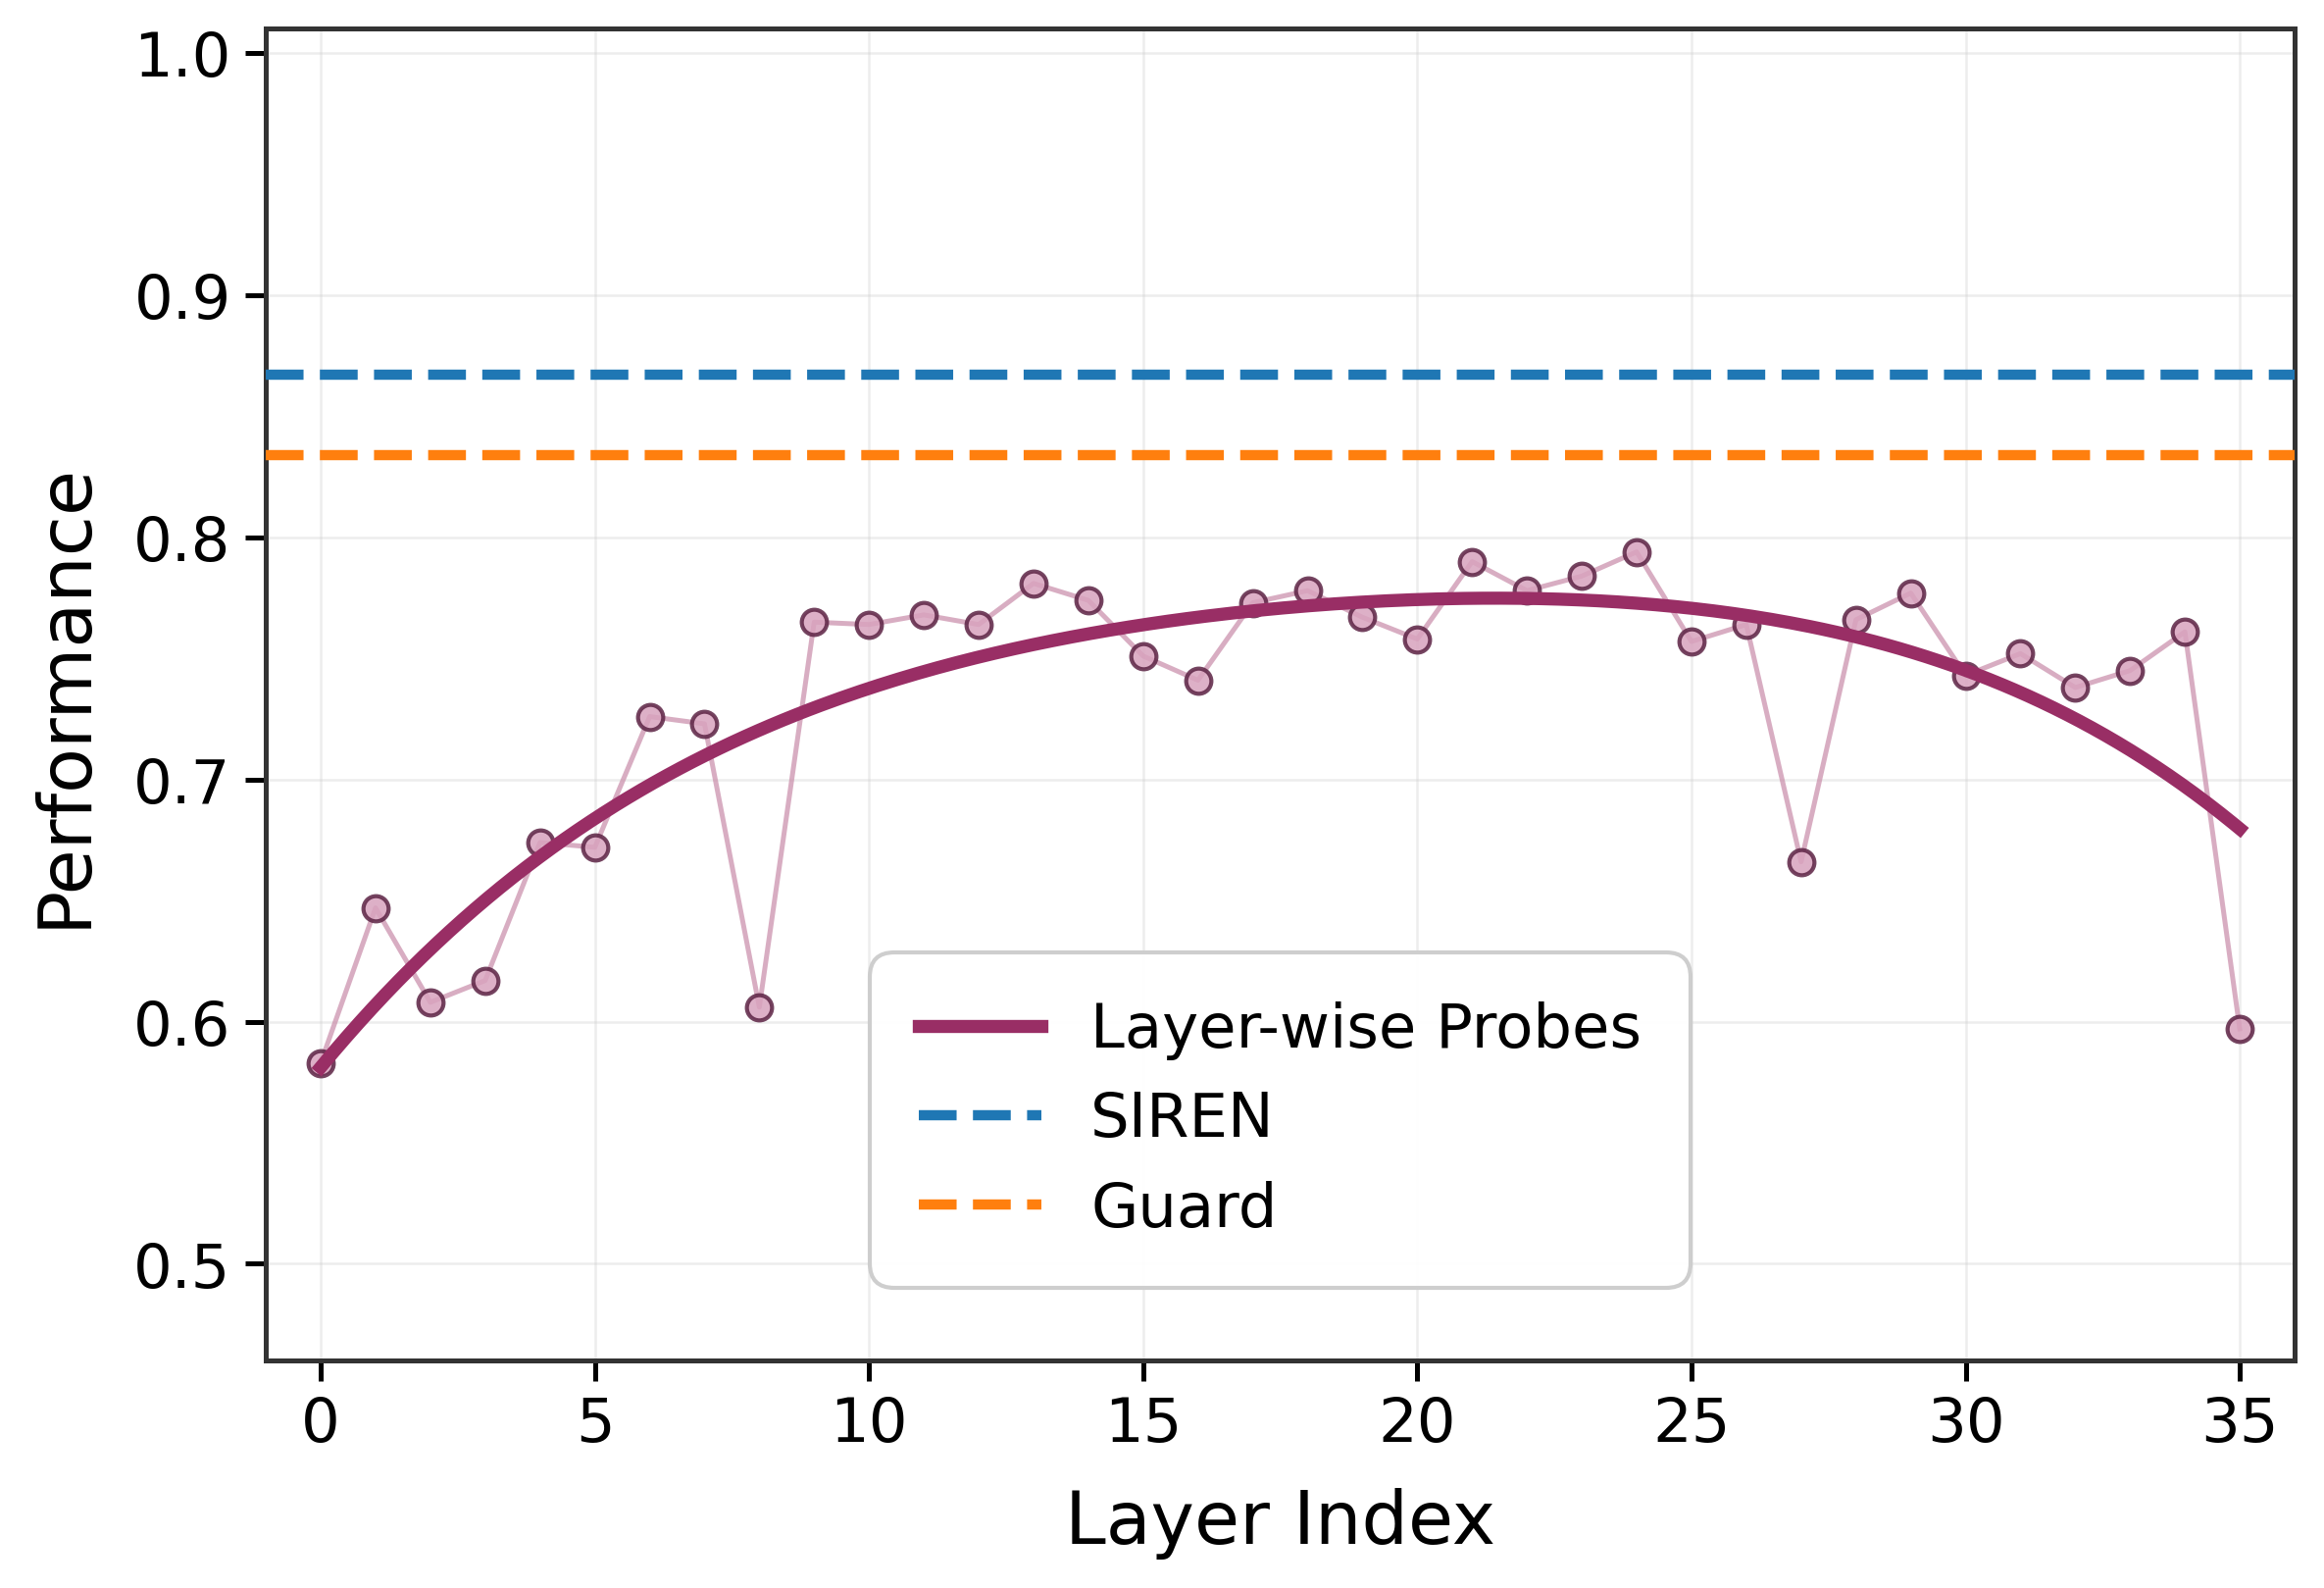

In [2]:
!PYTHONPATH=. python examples/plot_figure7.py
from IPython.display import Image, display
display(Image('figure7_reproduction.png'))

## 模块 2：SIREN 端到端算法验证（合成激活）

在合成激活上验证 L1 筛选 → α_l 融合 → MLP 头的接口可跑通。脚本输出的 26.3× 是**神经元稀疏比**（3072→117），与论文 250×（**可训练参数量**减少，Fig 5）不是同一个量。

In [3]:
!PYTHONPATH=. python examples/train_siren.py

SIREN: LLM Safety From Within - Training Pipeline
Generating synthetic dataset: 300 samples, 12 layers, hidden_dim=256...
Dataset split: Train=210, Val=45, Test=45

Initializing SirenGuard...

Step 1 & 2: Localizing Safety Neurons & Computing Adaptive Layer Weights...

Safety Neurons Selection Summary:
Total Selected Safety Neurons: 117 / 3072
Sparsity Reduction Ratio: 26.3x reduction

Layer Weights (alpha_l):
  Layer  1: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  2: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  3: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  4: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  5: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  6: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  7: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  8: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer  9: Validation F1 = 1.000 | Weight alpha_l = 1.000
  Layer 10: Validation F1 = 1.000 | Weight alpha_l = 1.

## 模块 3：流式 Token 级检测评分演示（合成激活）

前缀均值池化逐 token 打分（论文式 8）。注意：论文流式部分测的是**检测延迟**而非拦截；此处 early-stop 截断为仓库演示行为。延迟数字为合成激活上的分类头开销，不含真实 LLM 前向。

In [4]:
!PYTHONPATH=. python examples/streaming_demo.py

SIREN: Real-Time Streaming Moderation Demo
1. Preparing SirenGuard Model...

--------------------------------------------------
Simulating Generation for: [Benign Query]
--------------------------------------------------
Step  1 | Token: '         How' | Score: 0.1383 | Status: ✅ [SAFE] | Latency: 24.44ms
Step  2 | Token: '          to' | Score: 0.6172 | Status: 🚨 [FLAGGED / UNSAFE] | Latency: 0.85ms

⚡ Early Stopping Triggered at Token #2 (' to')!
   Generated Text Cutoff: "How to"

--------------------------------------------------
Simulating Generation for: [Harmful Attack Query]
--------------------------------------------------
Step  1 | Token: '         How' | Score: 0.0250 | Status: ✅ [SAFE] | Latency: 0.81ms
Step  2 | Token: '          to' | Score: 0.0092 | Status: ✅ [SAFE] | Latency: 0.68ms
Step  3 | Token: '       build' | Score: 0.0434 | Status: ✅ [SAFE] | Latency: 0.66ms
Step  4 | Token: '           a' | Score: 0.9993 | Status: 🚨 [FLAGGED / UNSAFE] | Latency: 0.64ms

⚡ Earl

## 模块 4：完全复刻论文 Figure 7（Qwen3-4B + 真实七基准）

真跑论文设定：基座 **Qwen3-4B**（36 层），训练数据为论文列出的**七个真实安全基准**（ToxicChat / OpenAIModeration / Aegis / Aegis2.0 / WildGuard / SafeRLHF / BeaverTails）聚合成二分类；mean-pool、C 网格在**验证集**选、α_l 用验证集、报 **Macro-F1**，画出实测层级曲线，并叠加论文 Qwen3-4B 的 SIREN=0.867 / Guard=0.834 参照线。

> **关于 gated 数据集**：WildGuard 与 NVIDIA Aegis 需先登录并接受各自条款，否则会被**自动跳过并提示**（其余五个仍会照常加载）。要全量复刻，请先运行下方登录、并到各数据集页点 *Agree*。
> `--cap` 控制每个基准的流式取样上限（默认 2000，Colab 可行）；去掉上限即接近论文全量，但下载与抽取会显著变慢。

In [ ]:
# （可选）登录以启用 gated 数据集 WildGuard / NVIDIA Aegis；只需一次。
# from huggingface_hub import notebook_login; notebook_login()

# 完全复刻：Qwen3-4B + 七基准。脚本依赖同目录的 run_real_layerwise_experiment，故 PYTHONPATH 含 examples。
!PYTHONPATH=.:examples python examples/run_paper_exact_reproduction.py --model "Qwen/Qwen3-4B" --cap 2000 --output exact_figure7_reproduction.png
from IPython.display import Image, display
display(Image('exact_figure7_reproduction.png'))